## Setup

In [4]:
# change into the src directory
import git
import os

repo = git.Repo('.', search_parent_directories=True)
os.chdir(repo.working_tree_dir)

In [5]:
from tapas_gmm_modified.policy.models.tpgmm import ModelType, TPGMM, ReconstructionStrategy, FittingStage, InitStrategy, _xdx_to_tangent, TPGMMConfig, AutoTPGMMConfig, AutoTPGMM, FrameSelectionConfig, DemoSegmentationConfig, CascadeConfig
# import lovely_tensors as lt
# lt.monkey_patch()
from lovely_numpy import lo
import matplotlib.pyplot as plt

import pathlib
#from pbdlib.utils.jupyter_utils import *
import numpy as np

from conf._machine import data_naming_config as machine_data_naming_config
from tapas_gmm_modified.dataset.demos import Demos, PartialFrameViewDemos
import tapas_gmm_modified.policy.models.tpgmm
from tapas_gmm_modified.utils.misc import load_scene_data, DataNamingConfig
from tapas_gmm_modified.utils.logging import setup_logger  # noqa: F401
from tapas_gmm_modified.viz.gmm import plot_log_map_quaternions, plot_hmm_transition_matrix

%matplotlib inline

%load_ext autoreload
%autoreload 2

data_root = pathlib.Path(machine_data_naming_config.data_root).resolve()
data_root = data_root.parent / data_root.stem

np.set_printoptions(precision=2)

plt.style.use('default')

from IPython.display import HTML
from matplotlib import rc
rc('animation', html='jshtml')


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [6]:
#task = 'TurnOnLight'
serie = 'demos'
task = 'OpenDrawerBack'
path = data_root / task / serie

data_config = DataNamingConfig(
    feedback_type=None,
    task=None,
    data_root=None,
    path=path,
)

scene_data = load_scene_data(data_config)
print(scene_data.sample_data_point_with_ground_truth(cam="wrist"))


2025-08-16 03:17:44.359 | INFO     |      Initializing datasete using /home/jangruhnert/Documents/GitHub/TapasCalvin/data/OpenDrawerBack/demos/metadata.json
2025-08-16 03:17:44.360 | INFO     |      Extracted gt object labels [0, 1, 2, 3, 4, 5, 6]
2025-08-16 03:17:44.360 | INFO     |      Extracted tsdf object labels []
2025-08-16 03:17:44.360 | INFO     |      Done! Data contains 5 trajectories.
SingleCamSceneObservation(
    action=Tensor(shape=torch.Size([7]), device=cpu, dtype=torch.float32, is_shared=False),
    depth=Tensor(shape=torch.Size([256, 256]), device=cpu, dtype=torch.float32, is_shared=False),
    ee_pose=Tensor(shape=torch.Size([7]), device=cpu, dtype=torch.float32, is_shared=False),
    extr=Tensor(shape=torch.Size([4, 4]), device=cpu, dtype=torch.float32, is_shared=False),
    feedback=Tensor(shape=torch.Size([1]), device=cpu, dtype=torch.float32, is_shared=False),
    intr=Tensor(shape=torch.Size([3, 3]), device=cpu, dtype=torch.float32, is_shared=False),
    mask=T

In [7]:
gt_pose_config = {
    #'indeces': [1,2,3,4],
}

gt_kp_config = {
    'encoder_name': 'demos_keypoints_gt_encoder-world',
    'cam': 'front',
}

kp_config = {
    'encoder_name': 'demos_vit_keypoints_encoder',
    'encoding_name': 'gtcopy',
}


In [8]:
observations = scene_data.get_demos(**gt_pose_config)
print(observations[0].keys())
print(observations[0])
n_obs = len(observations)

demo_meta_data = {
    'path': path
}

data_kwargs = dict(
    meta_data=demo_meta_data,
    add_init_ee_pose_as_frame=True,
    add_world_frame=False,
    frames_from_keypoints=False,
    kp_indeces=None,
    enforce_z_up=False,
    modulo_object_z_rotation=False,
    make_quats_continuous=True
)

demos = Demos(observations, **data_kwargs)
print(demos)

_LazyStackedTensorDictKeysView(['action', 'cameras', 'ee_pose', 'feedback', 'gripper_state', 'joint_pos', 'joint_vel', 'object_poses', 'object_states'],
    include_nested=False,
    leaves_only=False)
SceneObservation(
    action=Tensor(shape=torch.Size([75, 7]), device=cpu, dtype=torch.float32, is_shared=False),
    cameras=LazyStackedTensorDict(
        fields={
            _order: CameraOrder(
                order=('wrist',),
                batch_size=torch.Size([75]),
                device=None,
                is_shared=False),
            wrist: SingleCamObservation(
                depth=Tensor(shape=torch.Size([75, 256, 256]), device=cpu, dtype=torch.float32, is_shared=False),
                extr=Tensor(shape=torch.Size([75, 4, 4]), device=cpu, dtype=torch.float32, is_shared=False),
                intr=Tensor(shape=torch.Size([75, 3, 3]), device=cpu, dtype=torch.float32, is_shared=False),
                rgb=Tensor(shape=torch.Size([75, 3, 256, 256]), device=cpu, dtype=to

In [9]:
tag="release"

tpgmm_config = TPGMMConfig(
    n_components=10,
    model_type=ModelType.HMM,
    use_riemann=True,
    add_time_component=True,
    add_action_component=False,
    position_only=False,  # Use rotation aswell?
    add_gripper_action=True,
    heal_time_variance=False,
    reg_shrink=1e-2, # 1e-2 is 0.01
    reg_diag=2e-4,
    reg_diag_gripper=2e-2,
    reg_em_finish_shrink=1e-2,
    reg_em_finish_diag=2e-4,
    reg_em_finish_diag_gripper=2e-2,

    em_steps=50,
)

frame_selection_config = FrameSelectionConfig(
    init_strategy=InitStrategy.TIME_BASED,
    fitting_actions=(FittingStage.INIT,),
    rel_score_threshold=0.75,
    use_bic=False,  # Does prune segmentation
    drop_redundant_frames=True,
    gt_frames=[
        [0, 2],
        [0, 2],
        [0, 2],
    ],
)

demos_segmentation_config = DemoSegmentationConfig(
    gripper_based=False,
    distance_based=False,
    velocity_based=True,
    velocity_threshold=0.001,
    components_prop_to_len=True,
    min_end_distance=0,
)

cascade_config = CascadeConfig()

auto_tpgmm_config = AutoTPGMMConfig(
    tpgmm=tpgmm_config,
    frame_selection=frame_selection_config,
    demos_segmentation=demos_segmentation_config,
    cascade=cascade_config,
)

In [10]:
atpgmm = AutoTPGMM(auto_tpgmm_config)


2025-08-16 03:17:45.424 | INFO     |    Fitting AutoTPGMM
2025-08-16 03:17:45.424 | INFO     |    Performing fitting actions: [INIT]
2025-08-16 03:17:45.424 | INFO     |    Segmenting trajectories


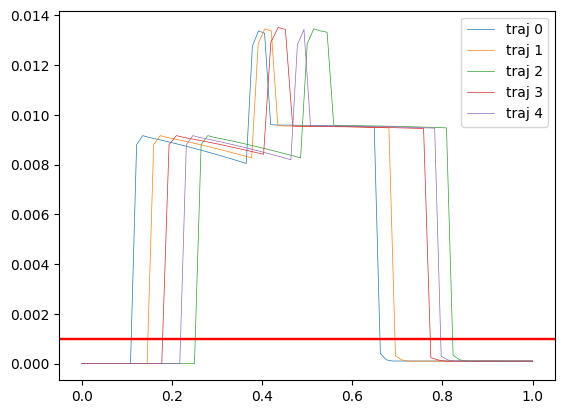

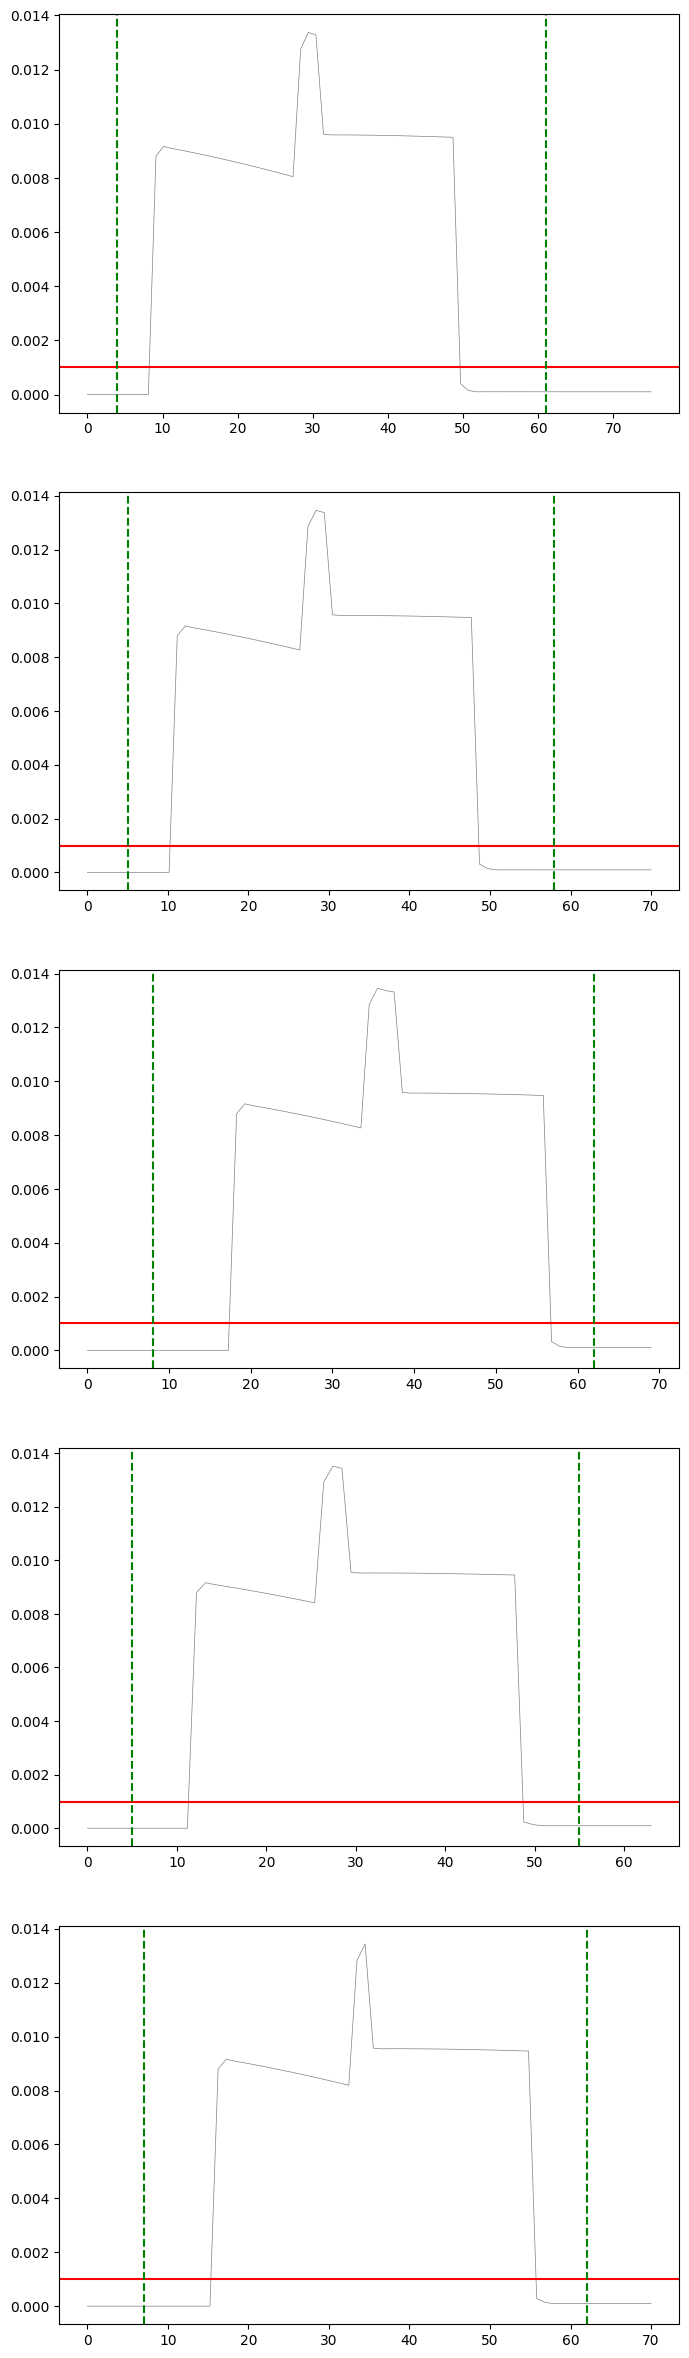

2025-08-16 03:17:45.801 | INFO     |    Creating segement of demos.
2025-08-16 03:17:45.803 | INFO     |    Subsampling to length 14 using strategy mean-length.
2025-08-16 03:17:45.803 | INFO     |    Creating segement of demos.
2025-08-16 03:17:45.805 | INFO     |    Subsampling to length 62 using strategy mean-length.
2025-08-16 03:17:45.805 | INFO     |    Creating segement of demos.
2025-08-16 03:17:45.806 | INFO     |    Subsampling to length 18 using strategy mean-length.
2025-08-16 03:17:45.807 | INFO     |    ... created 3 segments
2025-08-16 03:17:45.807 | INFO     |      Fitting candidate frame 1/10
2025-08-16 03:17:45.807 | INFO     |      Creating partial frame view of demos.
2025-08-16 03:17:45.808 | INFO     |      Manifold: TIME x R3 x QUAT x R1
2025-08-16 03:17:45.808 | INFO     |      Changing number of components to 1
2025-08-16 03:17:45.808 | INFO     |      Init strategy not specified. Auto selected InitStrategy.TIME_BASED.
2025-08-16 03:17:45.808 | INFO     |      

Time-based init:   0%|          | 0/1 [00:00<?, ?it/s]

2025-08-16 03:17:45.820 | INFO     |      Fitting candidate frame 2/10
2025-08-16 03:17:45.820 | INFO     |      Creating partial frame view of demos.


Time-based init:   0%|          | 0/1 [00:00<?, ?it/s]

2025-08-16 03:17:45.854 | INFO     |      Fitting candidate frame 3/10
2025-08-16 03:17:45.854 | INFO     |      Creating partial frame view of demos.


...

2025-08-16 03:17:47.274 | INFO     |    Manifold: TIME x R3 x QUAT x R3 x QUAT x R1
2025-08-16 03:17:47.274 | INFO     |    Changing number of components to 3


Time-based init:   0%|          | 0/3 [00:00<?, ?it/s]

Time-based init:   0%|          | 0/5 [00:00<?, ?it/s]

Time-based init:   0%|          | 0/3 [00:00<?, ?it/s]

((array([[1.00e+24, 1.00e+24, 6.94e+23, 3.32e+23, 1.10e+23, 2.51e+22,
          3.97e+21, 4.35e+20, 3.29e+19, 1.72e+18, 6.24e+16, 1.56e+15,
          2.70e+13, 3.24e+11, 1.00e+24, 1.00e+24, 6.94e+23, 3.32e+23,
          1.10e+23, 2.51e+22, 3.98e+21, 4.35e+20, 3.29e+19, 1.72e+18,
          6.24e+16, 1.56e+15, 2.71e+13, 3.24e+11, 1.00e+24, 1.00e+24,
          6.94e+23, 3.32e+23, 1.10e+23, 2.51e+22, 3.98e+21, 4.35e+20,
          3.29e+19, 1.72e+18, 6.24e+16, 1.56e+15, 2.71e+13, 3.24e+11,
          1.00e+24, 1.00e+24, 6.94e+23, 3.32e+23, 1.10e+23, 2.51e+22,
          3.98e+21, 4.35e+20, 3.29e+19, 1.72e+18, 6.24e+16, 1.56e+15,
          2.71e+13, 3.24e+11, 1.00e+24, 1.00e+24, 6.94e+23, 3.32e+23,
          1.10e+23, 2.51e+22, 3.98e+21, 4.35e+20, 3.29e+19, 1.72e+18,
          6.24e+16, 1.56e+15, 2.71e+13, 3.24e+11],
         [4.89e+23, 9.00e+23, 1.10e+24, 9.00e+23, 4.89e+23, 1.77e+23,
          4.28e+22, 6.88e+21, 7.37e+20, 5.25e+19, 2.50e+18, 7.91e+16,
          1.67e+15, 2.34e+13, 4.90e+23,

In [11]:
atpgmm.fit_trajectories(demos, fix_frames=True,
                       fitting_actions=(FittingStage.INIT,))


2025-08-16 03:17:47.598 | INFO     |    Did not specify time_based, deciding automatically.


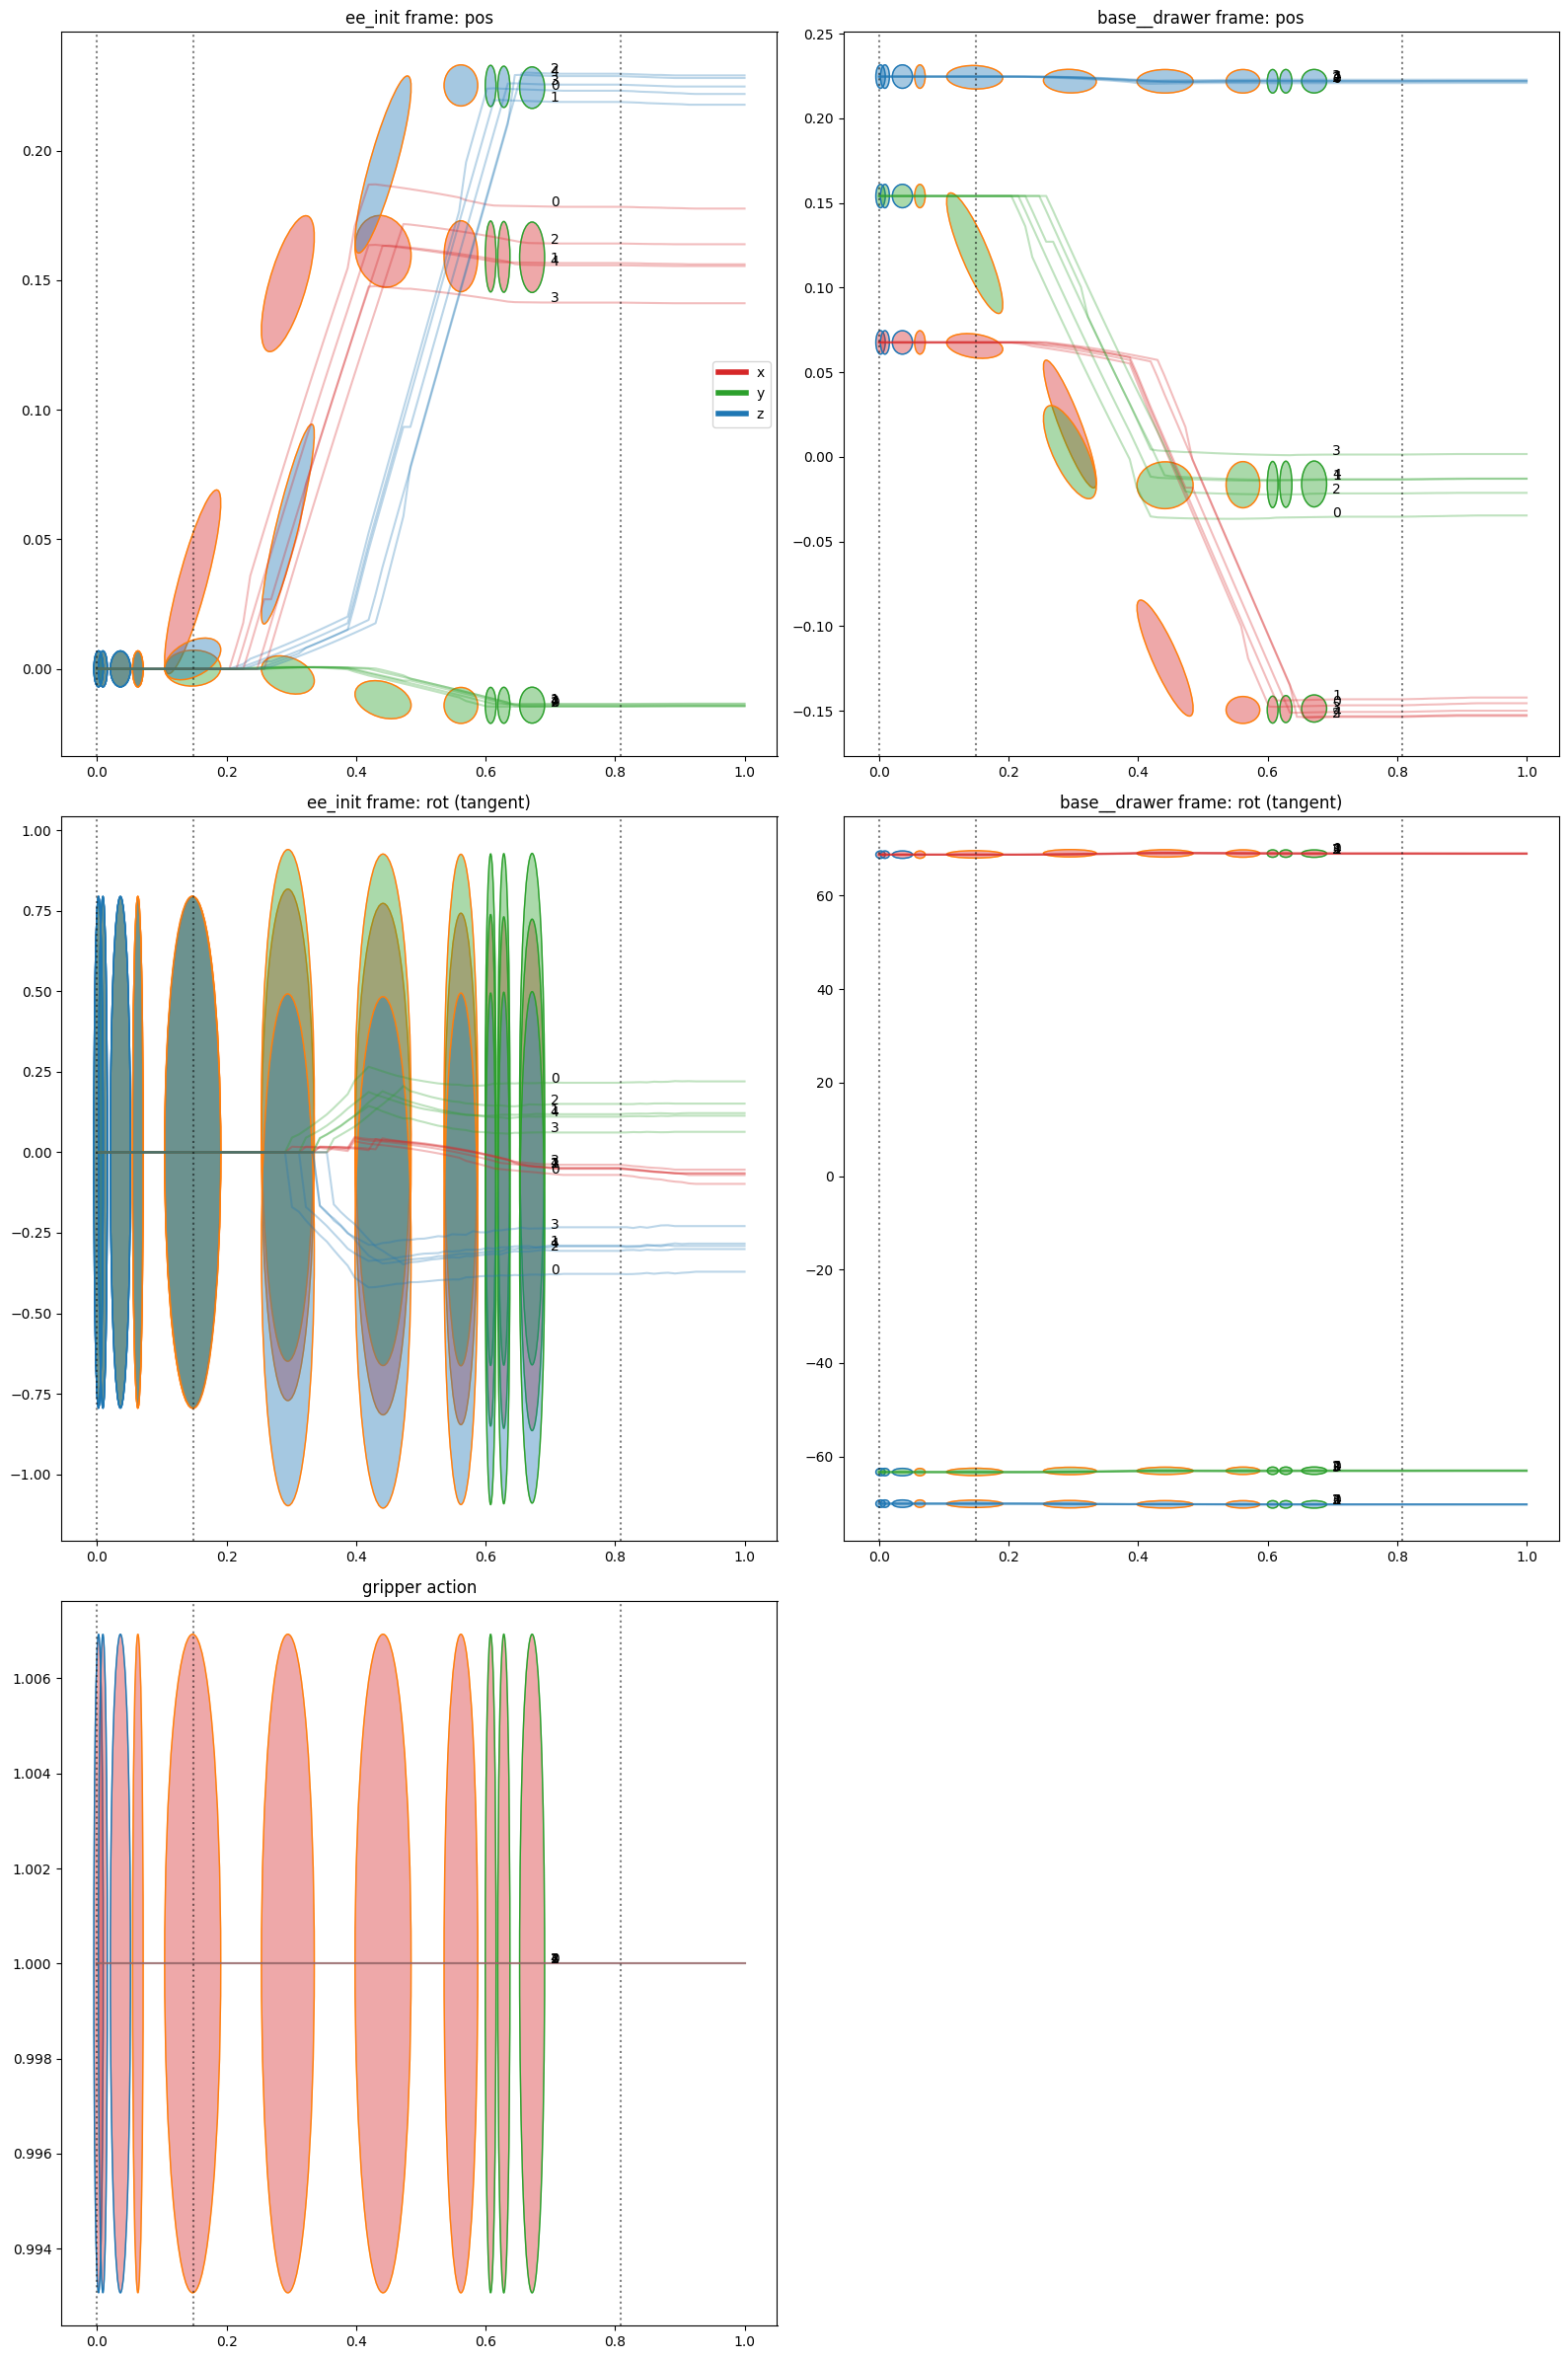

In [12]:
atpgmm.plot_model(
    scatter=True, rotations_raw=True, plot_traj=True, plot_gaussians=True,
    annotate_gaussians=False, annotate_trajs=True,
    mean_as_base=False, per_segment=False, gaussian_mean_only=False, plot_traj_means=False) #, size=(150, 10))


In [13]:
atpgmm.fit_trajectories(demos, fix_frames=True,
                       fitting_actions=(FittingStage.EM_HMM, ))


2025-08-16 03:17:48.377 | INFO     |    Fitting AutoTPGMM
2025-08-16 03:17:48.377 | INFO     |    Performing fitting actions: [EM_HMM]


Fitting segments:   0%|          | 0/3 [00:00<?, ?it/s]

2025-08-16 03:17:48.381 | INFO     |    HMM EM ...
2025-08-16 03:17:48.382 | INFO     |    HMM transition matrix not defined, initializing to uniform


HMM EM:   0%|          | 0/50 [00:00<?, ?it/s]

2025-08-16 03:17:48.390 | INFO     |    HMM init priors not defined, initializing to uniform
2025-08-16 03:17:48.562 | INFO     |    HMM EM converged


HMM EM:   0%|          | 0/50 [00:00<?, ?it/s]

HMM EM:   0%|          | 0/50 [00:00<?, ?it/s]

((array([[8.38e-09, 7.79e-09, 5.49e-09, 1.90e-09, 1.88e-10, 3.41e-12,
          7.99e-15, 1.80e-18, 2.91e-23, 2.52e-29, 8.82e-37, 9.32e-46,
          4.13e-56, 1.70e-61, 8.38e-09, 7.79e-09, 5.49e-09, 1.90e-09,
          1.88e-10, 3.40e-12, 7.99e-15, 1.80e-18, 2.91e-23, 2.52e-29,
          8.82e-37, 9.32e-46, 4.13e-56, 1.70e-61, 8.38e-09, 7.79e-09,
          5.49e-09, 1.90e-09, 1.88e-10, 3.40e-12, 7.99e-15, 1.80e-18,
          2.91e-23, 2.52e-29, 8.82e-37, 9.32e-46, 4.13e-56, 1.70e-61,
          8.38e-09, 7.79e-09, 5.49e-09, 1.90e-09, 1.88e-10, 3.40e-12,
          7.99e-15, 1.80e-18, 2.91e-23, 2.52e-29, 8.82e-37, 9.32e-46,
          4.13e-56, 1.70e-61, 8.38e-09, 7.79e-09, 5.49e-09, 1.90e-09,
          1.88e-10, 3.40e-12, 7.99e-15, 1.80e-18, 2.91e-23, 2.52e-29,
          8.82e-37, 9.32e-46, 4.13e-56, 1.70e-61],
         [3.43e-20, 5.95e-10, 2.30e-09, 3.60e-09, 1.71e-09, 1.85e-10,
          3.40e-12, 8.00e-15, 1.81e-18, 3.10e-23, 4.52e-29, 1.82e-35,
          4.12e-42, 1.00e-48, 3.43e-20,

2025-08-16 03:17:50.830 | INFO     |    Did not specify time_based, deciding automatically.


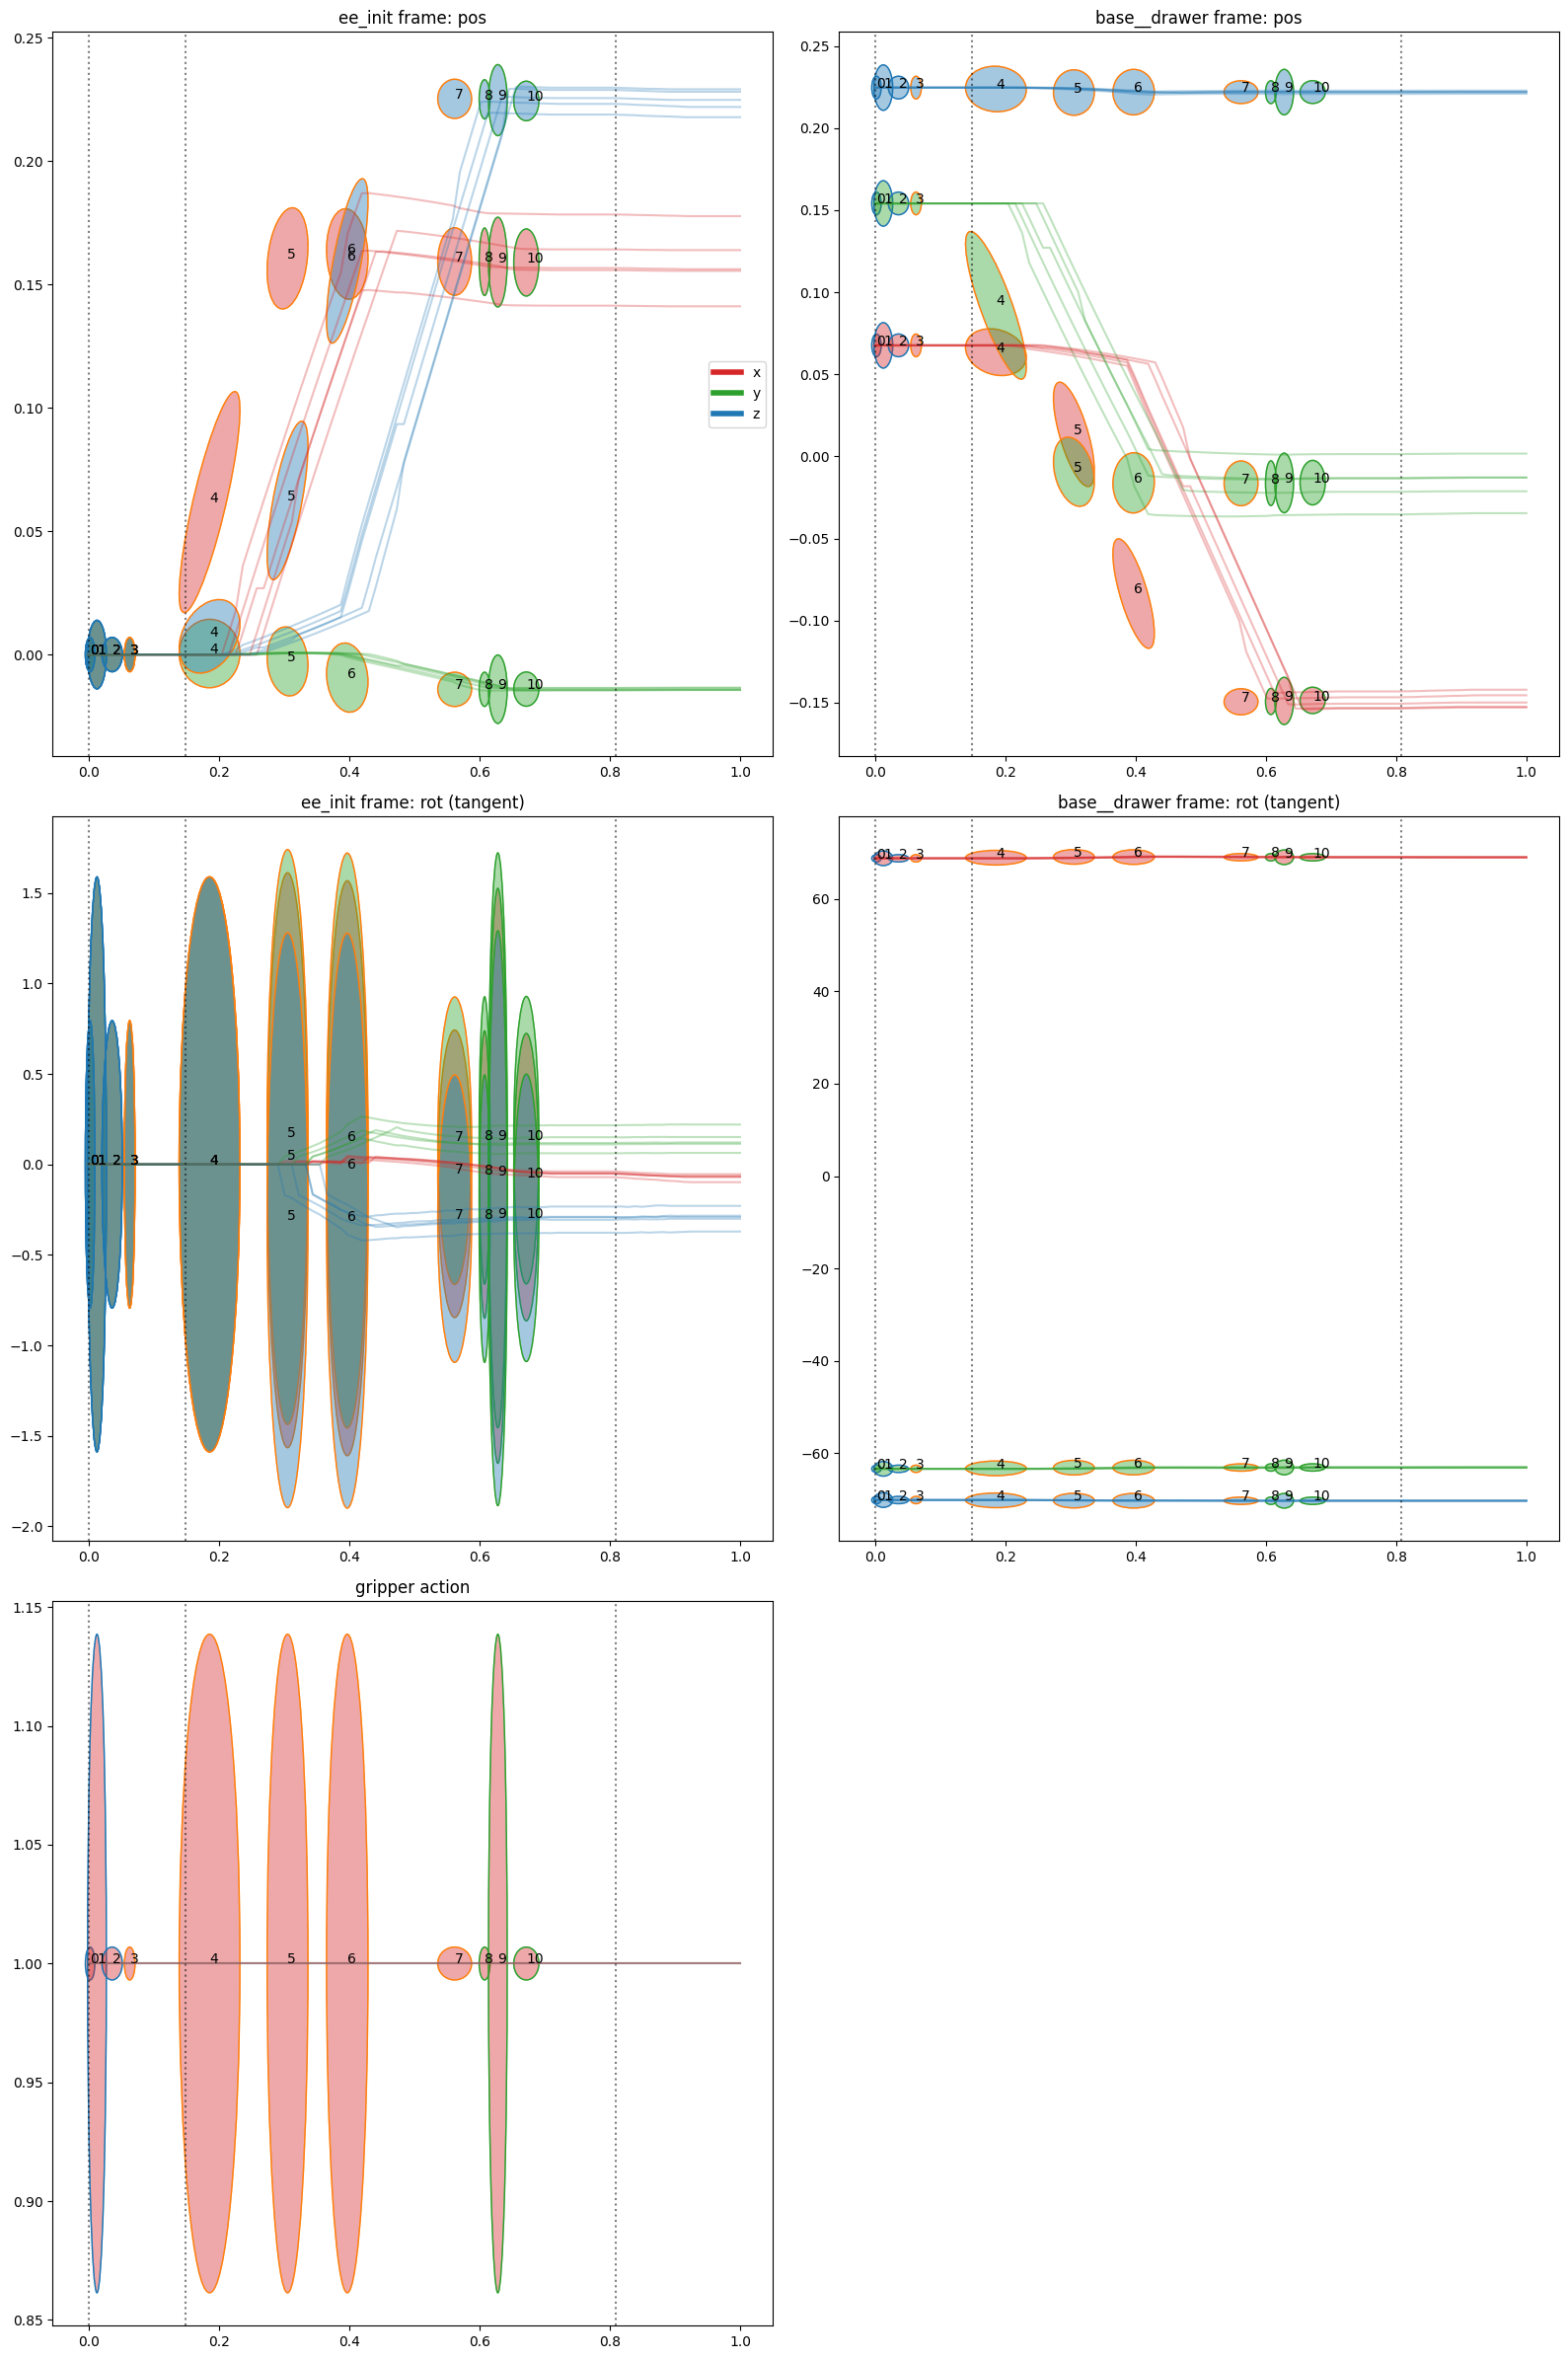

In [14]:

atpgmm.plot_model(
    scatter=True, rotations_raw=True, plot_traj=True, plot_gaussians=True,
    annotate_gaussians=True, annotate_trajs=False,
    mean_as_base=False, per_segment=False, gaussian_mean_only=False, plot_traj_means=False)

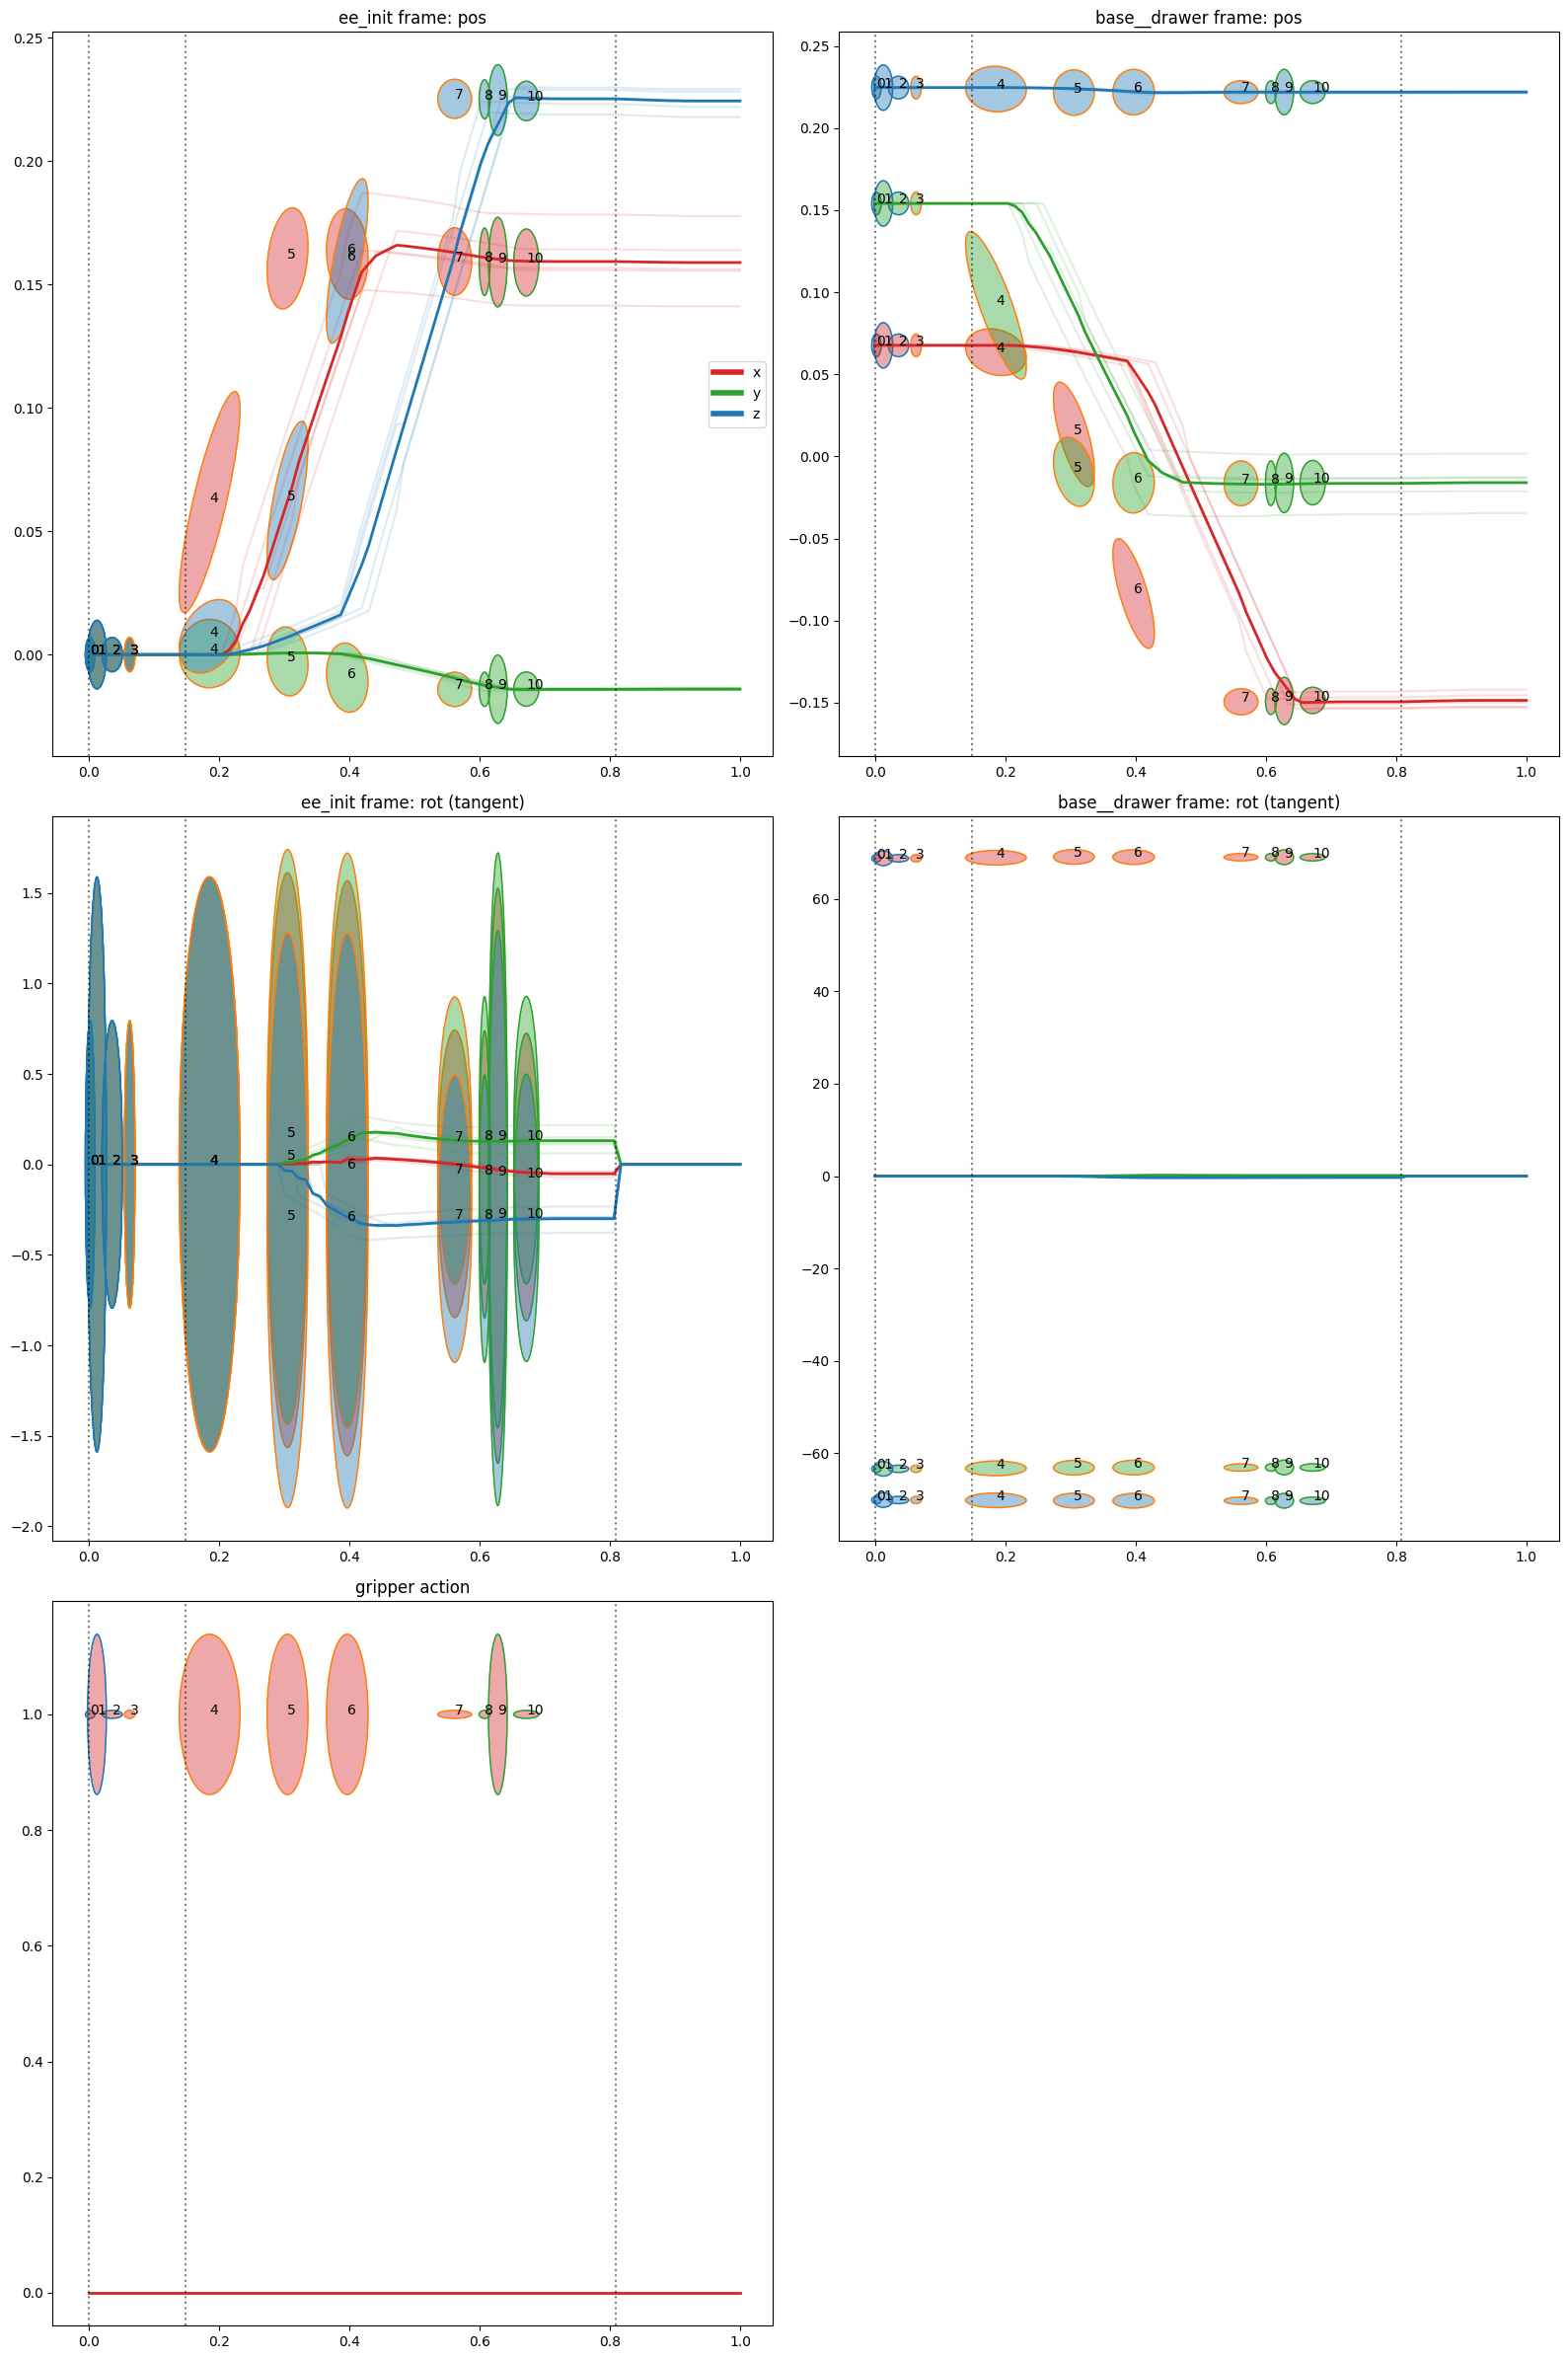

In [15]:
atpgmm.plot_model(
    scatter=True, rotations_raw=True, plot_traj=True, plot_gaussians=True,
    annotate_gaussians=True, annotate_trajs=False,
    mean_as_base=True, per_segment=False, gaussian_mean_only=False, plot_traj_means=True, time_based=True)

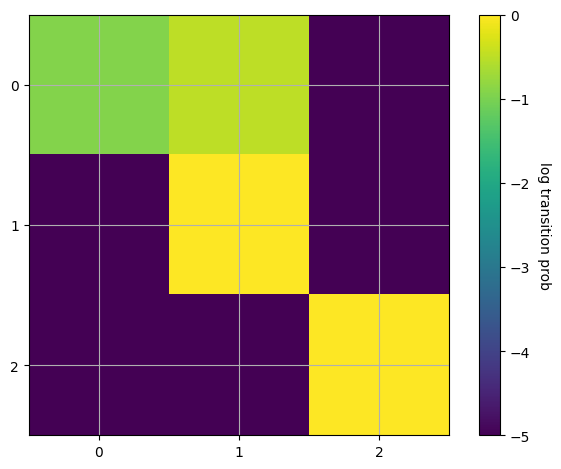

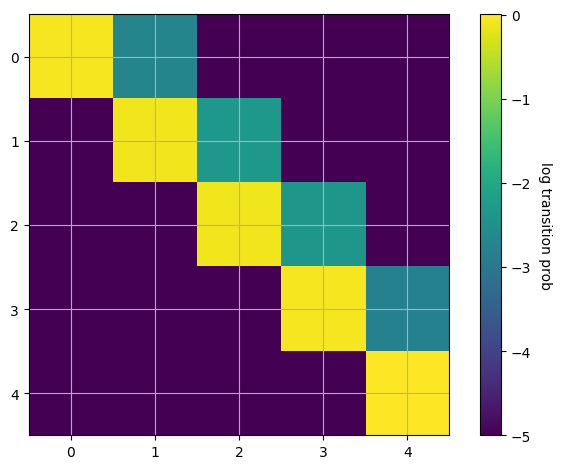

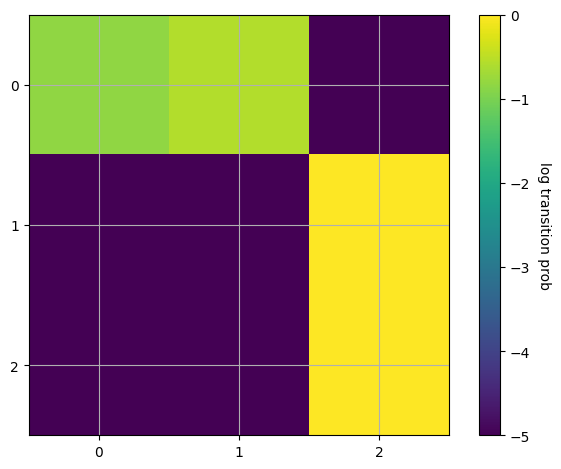

In [16]:
atpgmm.plot_hmm_transition_matrix()

In [17]:
atpgmm.to_disk(data_root / task / f'{serie}_gmm_policy-{tag}.pt')

2025-08-16 03:17:53.126 | INFO     |    Saving model:


In [18]:
seg_local_marginals, seg_trans_marginals, seg_trans_marg_container, seg_joint_models, cascaded_hmms, (reconstructions, original_trajectories, extras) = atpgmm.reconstruct(
    strategy=tapas_gmm_modified.policy.models.tpgmm.ReconstructionStrategy.GMR,
    use_ss=False)


2025-08-16 03:17:53.183 | INFO     |    Time-based reconstruction not specified. Auto selected True.
2025-08-16 03:18:10.929 | INFO     |    Caculated segment transition probabilities: (array([[0.]]), array([[1.88e-08]]))
2025-08-16 03:18:10.929 | WARNING  |    At least one segment transition prob below 5%. Can lead to problems.Consider increasing the diag reg.
2025-08-16 03:18:10.929 | INFO     |    Creating partial frame view of demos.
2025-08-16 03:18:10.931 | INFO     |    Assuming zero frame velocity. Should be fixed.


Transforming marginals:   0%|          | 0/5 [00:00<?, ?it/s]

Joining marginals:   0%|          | 0/5 [00:00<?, ?it/s]

2025-08-16 03:18:10.961 | INFO     |    Creating partial frame view of demos.


Transforming marginals:   0%|          | 0/5 [00:00<?, ?it/s]

...

2025-08-16 03:18:10.992 | INFO     |    Creating partial frame view of demos.


Transforming marginals:   0%|          | 0/5 [00:00<?, ?it/s]

Joining marginals:   0%|          | 0/5 [00:00<?, ?it/s]

2025-08-16 03:18:11.016 | WARNING  |    Setting init priors of later segments to zero.


GMR:   0%|          | 0/5 [00:00<?, ?it/s]

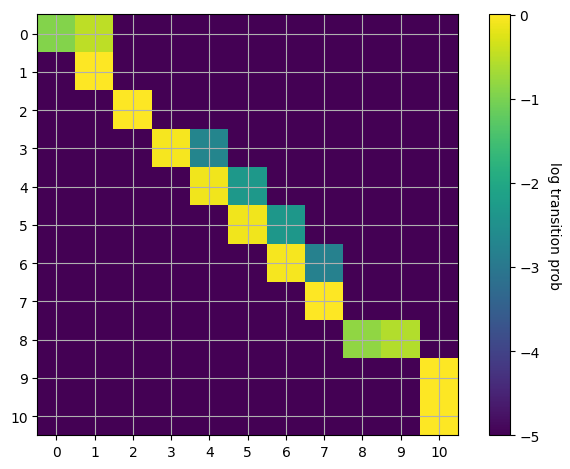

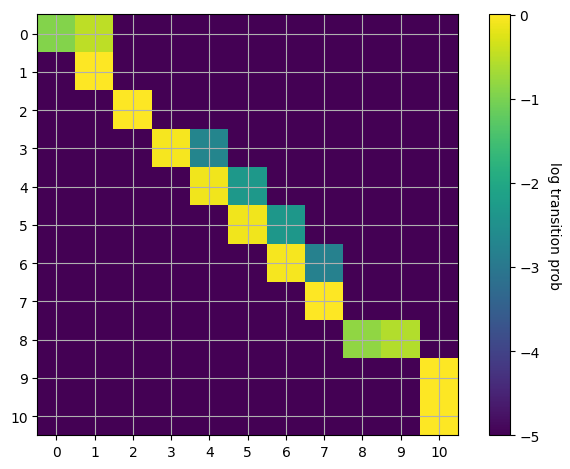

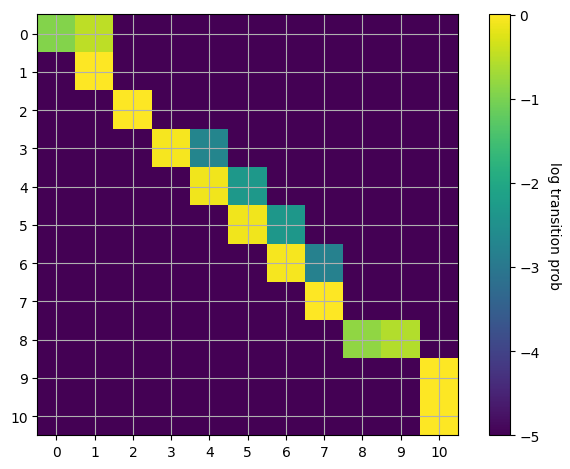

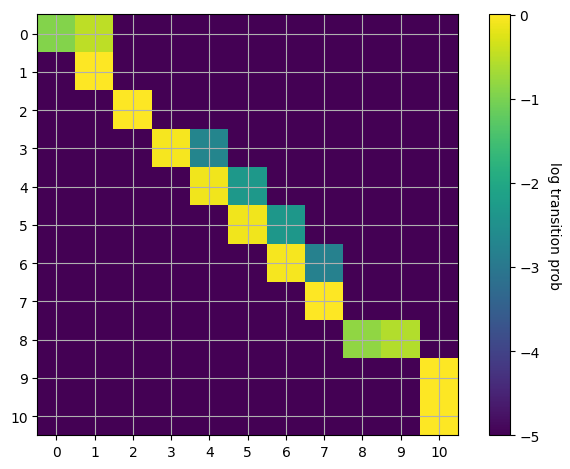

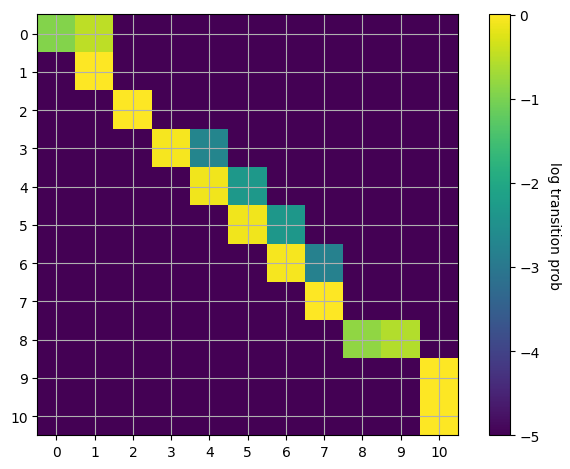

In [19]:
for cascaded_hmm in cascaded_hmms:
    plot_hmm_transition_matrix(cascaded_hmm)

2025-08-16 03:18:12.250 | INFO     |    Taking frame origins from demos.


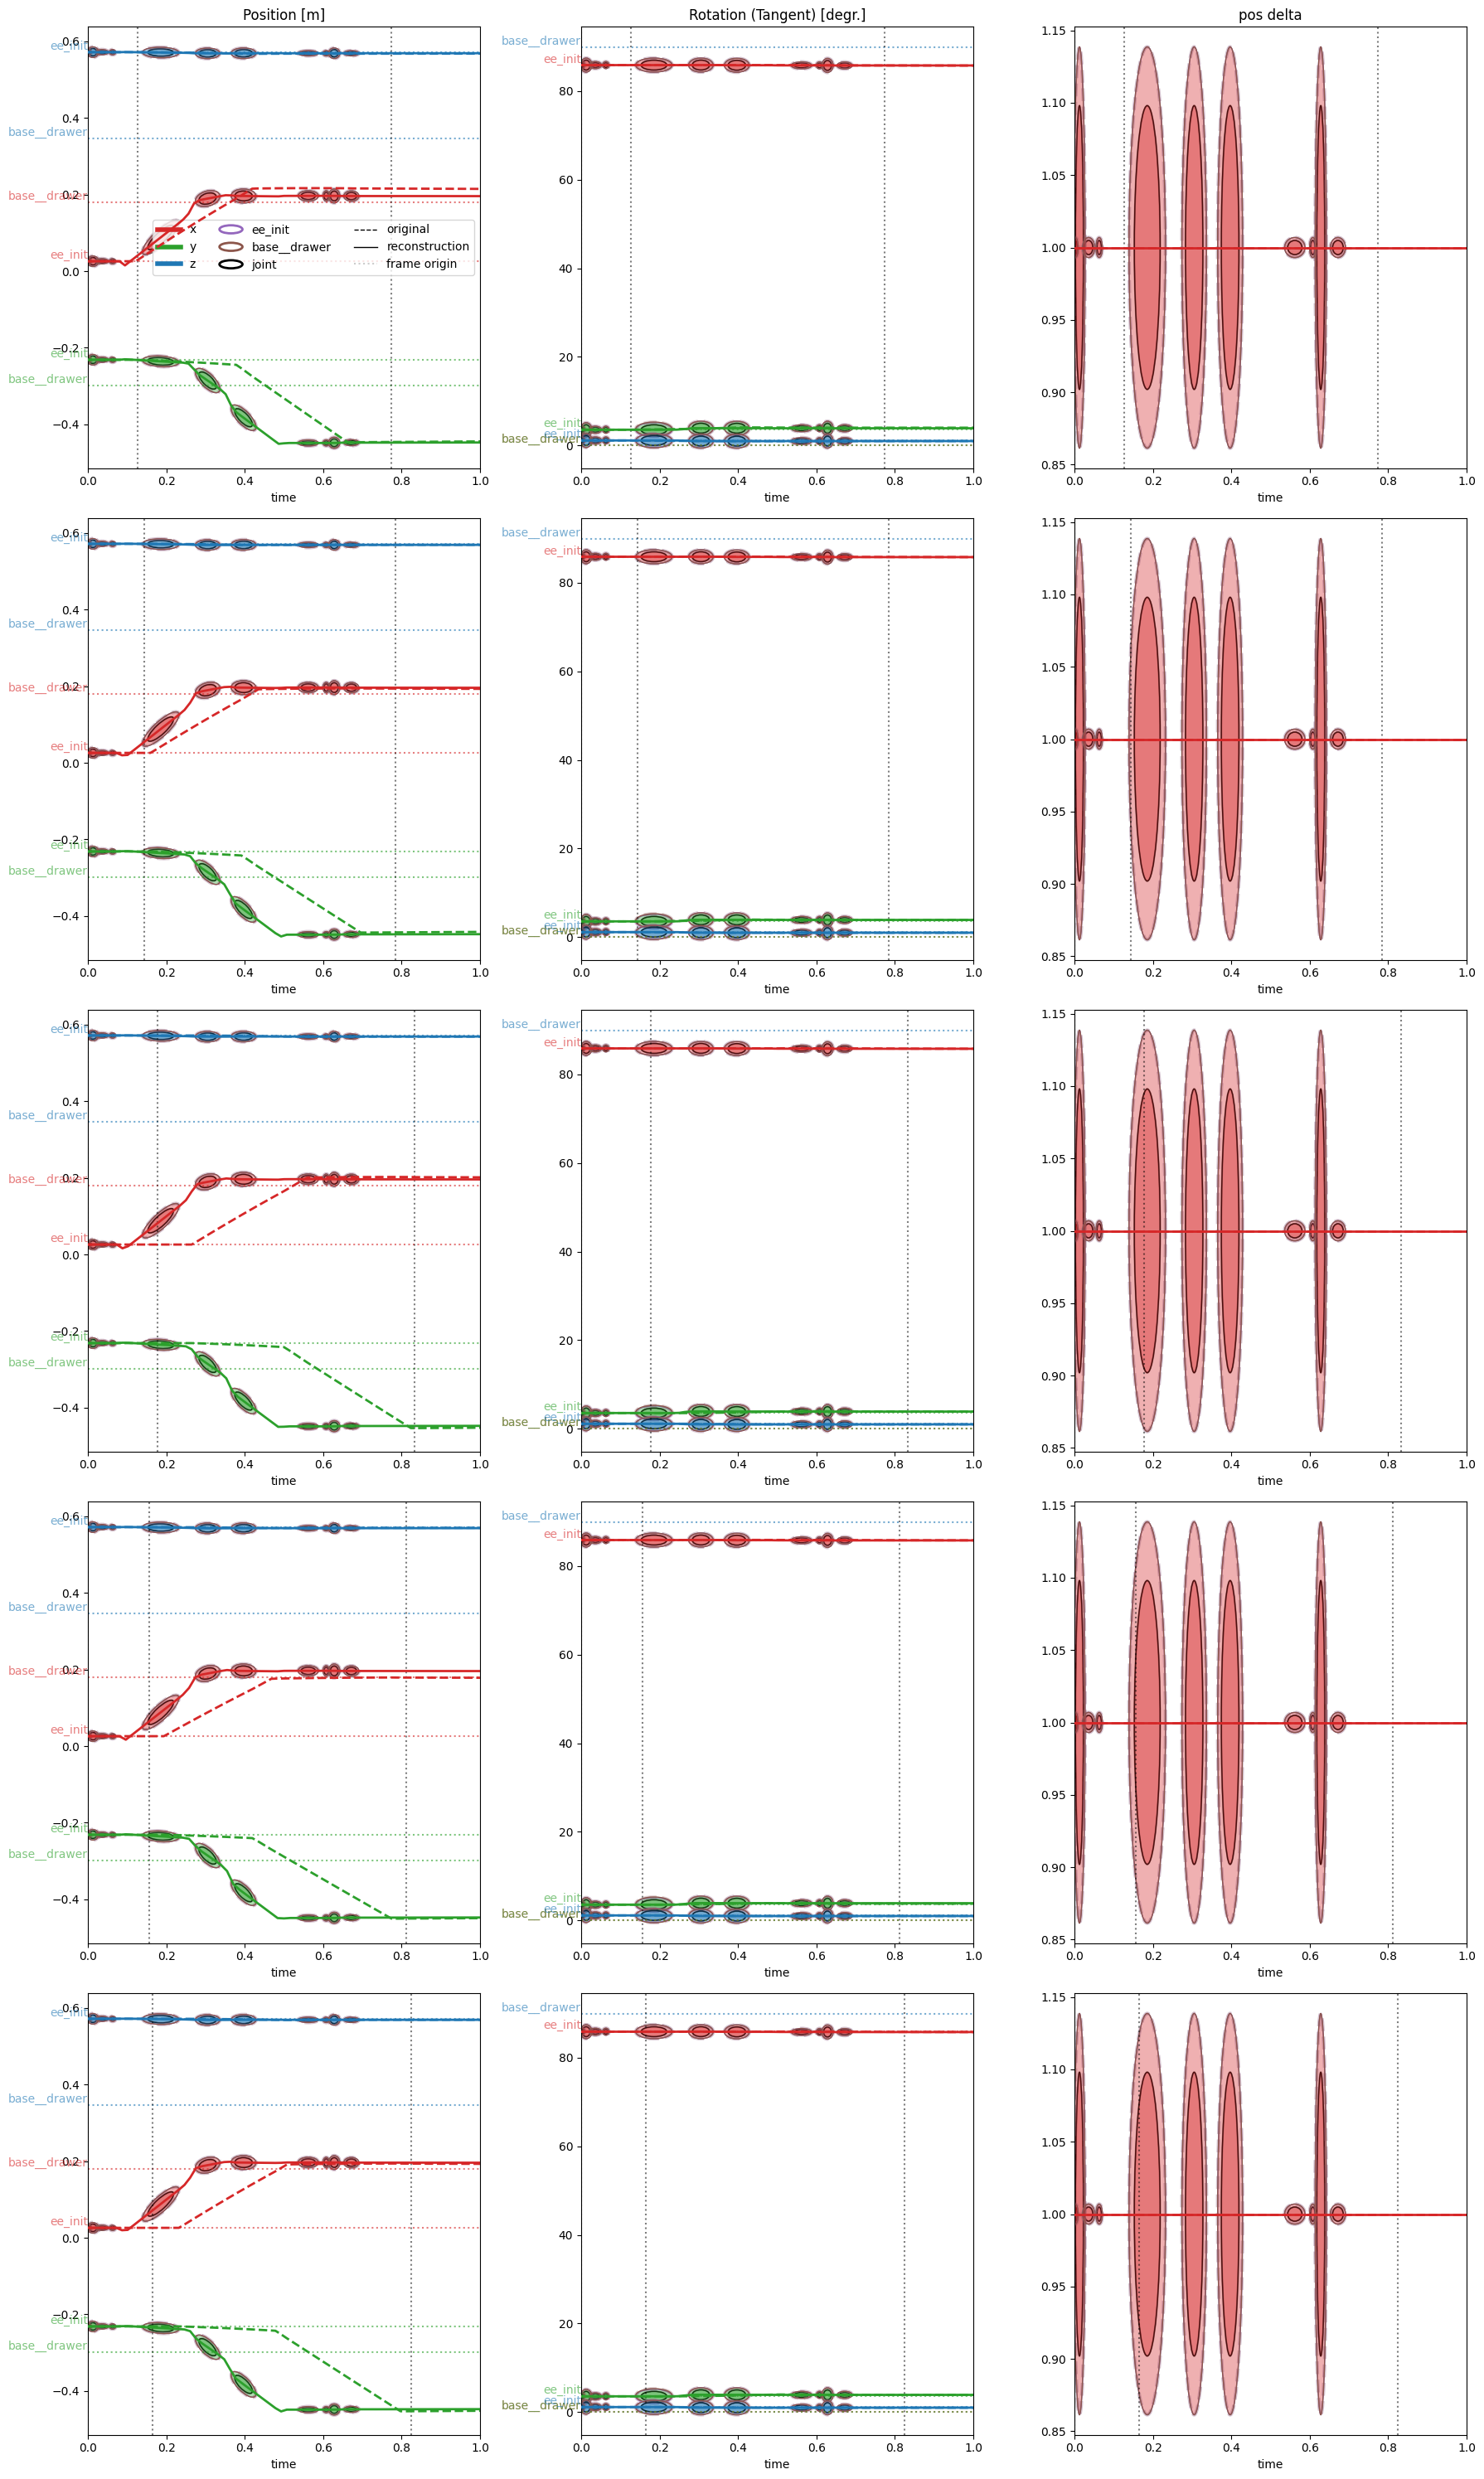

In [20]:
atpgmm.plot_reconstructions(
    seg_trans_marg_container,
    cascaded_hmms,
    reconstructions,
    original_trajectories,
    plot_trajectories=True,
    plot_reconstructions=True,
    plot_gaussians=True,
    time_based=True,
    equal_aspect=False,
    per_segment=False,
)

In [21]:
atpgmm.plot_reconstructions(
    seg_trans_marginals,
    seg_joint_models,
    reconstructions,
    original_trajectories,
    plot_trajectories=True,
    plot_reconstructions=True,
    plot_gaussians=True,
    time_based=True,
    equal_aspect=True,
    per_segment=False,
)

2025-08-16 03:18:16.043 | INFO     |    Taking frame origins from demos.


AttributeError: 'tuple' object has no attribute 'np_to_manifold_to_np'